# FLIP-IT CKD — federated protocols, accuracy and privacy

A reproducible experiment for the FLIP-IT pre-kickoff baseline. Run top to bottom, then
**File → Save and Export Notebook As → PDF** (or `jupyter nbconvert --to pdf`) for a circulable
document. Full run takes roughly 5–10 minutes.

It answers four questions with measurements rather than assertions:

1. How close does federation get to the **pooled-data ceiling** — one model trained on everything?
2. Do the protocols beat a practice that never collaborates?
3. Does training longer help?
4. What does privacy cost, and is secure aggregation even reachable?

Everything runs on **synthetic** data standing in for HL7-FHIR practice data. Absolute AUROC is not
a clinical claim; the *relative ordering* is the transferable result.

---
### Setup
```bash
uv sync --extra dev --extra notebook
uv run ckd-clinics --clinics 10      # generates data/clinics/
```


In [1]:
import sys, warnings, logging, contextlib, io, time
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib as mpl
from matplotlib.patches import Patch

logging.getLogger('flwr').setLevel(logging.ERROR)
warnings.filterwarnings('ignore')

from data import load_clinic_frames, to_xy
from data.synthesize import ARCHETYPES
from simulate import run_simulation
from centralized import run_centralized
from privacy import run_dp_sweep, probe_secagg

# ── experiment configuration ────────────────────────────────────────────
SEEDS      = [42, 43, 44, 45, 46]   # every number below is averaged over these
ROUNDS     = 50                     # run long, then look at where it converged
CHECKPOINTS = [5, 10, 20, 35, 50]
DP_ROUNDS  = 20

PROTOCOLS = ['fedprox', 'fedxgb', 'fedmosaic']
BASELINES = ['local', 'fedavg']
ALL_RUNS  = PROTOCOLS + BASELINES

COLOR = {'fedmosaic':'#2a78d6', 'fedprox':'#eb6834', 'fedxgb':'#1baf7a',
         'fedavg':'#8695a1', 'local':'#b8c2ca'}
INK, MUTED, GRID = '#141d24', '#5c6b77', '#e3e9ed'
CEIL = '#141d24'

mpl.rcParams.update({
    'figure.dpi':130, 'savefig.dpi':130, 'font.size':9.5,
    'axes.titlesize':11, 'axes.labelsize':9.5,
    'axes.edgecolor':GRID, 'axes.labelcolor':INK, 'text.color':INK,
    'xtick.color':MUTED, 'ytick.color':MUTED,
    'axes.spines.top':False, 'axes.spines.right':False,
    'axes.grid':True, 'grid.color':GRID, 'grid.linewidth':.7,
    'figure.facecolor':'white', 'axes.facecolor':'white', 'legend.frameon':False,
})
print(f'{len(SEEDS)} seeds x {ROUNDS} rounds x {len(ALL_RUNS)} comparators')


5 seeds x 50 rounds x 5 comparators


---
## 1. The cohort

Ten synthetic GP practices, each a different population, all sharing **one true underlying risk
model** — so there is a global truth worth learning.


In [2]:
frames = load_clinic_frames()
cohort = pd.DataFrame([
    {'practice': i, 'patients': len(to_xy(df)[1]), 'CKD rate': to_xy(df)[1].mean()}
    for i, df in enumerate(frames)
]).set_index('practice')

print(f"{len(frames)} practices | {cohort['patients'].sum():,} patients")
print(f"panel size  {cohort['patients'].min()}-{cohort['patients'].max()}")
print(f"CKD rate    {cohort['CKD rate'].min():.1%}-{cohort['CKD rate'].max():.1%}")
print(f"archetypes  {', '.join(a.name for a in ARCHETYPES)}")
cohort.style.format({'CKD rate':'{:.1%}'})


10 practices | 3,276 patients
panel size  161-532
CKD rate    8.3%-46.0%
archetypes  urban-young, rural-elderly, metabolic, high-cvd, mixed


,patients,CKD rate
practice,,
0,162,10.5%
1,492,42.7%
2,434,34.6%
3,331,42.3%
4,328,18.3%
5,532,8.3%
6,161,46.0%
7,455,40.0%
8,216,43.5%


A 161-patient practice at 8 % prevalence is a very different estimation problem from a 532-patient
practice at 46 % — **quantity**, **label** and **covariate** shift at once. That is what breaks
naive averaging and what the protocols compete to handle.


---
## 2. What is being compared

Two things below are *not* like-for-like, and both matter when reading results.

**Model class.** Four rows are logistic regression. `fedxgb` is XGBoost — a different model class,
reported alongside rather than head-to-head.

**One global model vs. per-practice models.** `fedavg`, `fedprox` and `fedxgb` produce a *single*
model scored on every practice's patients. `local` and `fedmosaic` produce **ten different** models,
each scored on its own patients. That measures what a practice would actually deploy — but
personalized methods are allowed to specialize, so keep the distinction in view.

**And the ceiling.** `centralized` is one model trained on **all practices' data pooled into one
place** — forbidden in reality, and the upper bound federation is trying to reach.


In [3]:
spec = pd.DataFrame([
    {'run':'centralized','kind':'ceiling',  'model':'logistic regression','strategy':'none - all data pooled',
     'model scope':'one global','on the wire':'n/a - data centralised (not permitted in reality)'},
    {'run':'fedprox',    'kind':'protocol','model':'logistic regression','strategy':'FedProx (Flower built-in)',
     'model scope':'one global','on the wire':'model coefficients'},
    {'run':'fedxgb',     'kind':'protocol','model':'XGBoost',            'strategy':'FedXgbBagging (Flower built-in)',
     'model scope':'one global','on the wire':'serialized decision trees'},
    {'run':'fedmosaic',  'kind':'protocol','model':'logistic regression','strategy':'FedMosaic (Strategy subclass)',
     'model scope':'per practice','on the wire':'predictions + expertise on a public cohort'},
    {'run':'fedavg',     'kind':'baseline','model':'logistic regression','strategy':'FedAvg (Flower built-in)',
     'model scope':'one global','on the wire':'model coefficients'},
    {'run':'local',      'kind':'baseline','model':'logistic regression','strategy':'none - no collaboration',
     'model scope':'per practice','on the wire':'nothing'},
]).set_index('run')
spec


,kind,model,strategy,model scope,on the wire
run,,,,,
centralized,ceiling,logistic regression,none - all data pooled,one global,n/a - data centralised (not permitted in reality)
fedprox,protocol,logistic regression,FedProx (Flower built-in),one global,model coefficients
fedxgb,protocol,XGBoost,FedXgbBagging (Flower built-in),one global,serialized decision trees
fedmosaic,protocol,logistic regression,FedMosaic (Strategy subclass),per practice,predictions + expertise on a public cohort
fedavg,baseline,logistic regression,FedAvg (Flower built-in),one global,model coefficients
local,baseline,logistic regression,none - no collaboration,per practice,nothing


### How `local` and the worst-practice column are scored

For `local`, each practice trains **only on its own rows**, keeps **its own** model, and is scored
on **its own** held-out 20 %. Those ten per-practice scores are then combined exactly like every
other row:

- **AUROC** — sample-weighted mean across practices, weighted by test-set size
- **Worst practice** — the minimum across practices

`local` is the honest "what if we never collaborated" floor.


---
## 3. Running the experiment

Every comparator, every seed, 50 rounds, recording the full curve so we can read off any round.
Two datasets:

- **clinics** — signal-bearing non-IID practices. The real comparison.
- **flat** — the placeholder CSV, max |feature-label correlation| 0.031. The **negative control**:
  anything meaningfully above 0.5 here is a bug, not a result.


In [4]:
def run_one(dataset, protocol, seed, rounds=ROUNDS):
    with contextlib.redirect_stdout(io.StringIO()):
        return run_simulation(num_practices=12, num_rounds=rounds, quiet=True,
                              clinics_dir=True if dataset=='clinics' else None,
                              protocol=protocol, seed=seed)

hist = {}
t0 = time.perf_counter()
for dataset in ['clinics', 'flat']:
    for run in ALL_RUNS:
        for seed in SEEDS:
            hist[(dataset, run, seed)] = run_one(dataset, run, seed)
    print(f'  {dataset} done  ({time.perf_counter()-t0:.0f}s)')

def at_round(dataset, run, seed, r, key='auc'):
    return hist[(dataset, run, seed)][r-1].get(key, np.nan)

print(f'{len(hist)} runs in {time.perf_counter()-t0:.0f}s')


  clinics done  (94s)


  flat done  (191s)
50 runs in 191s


In [5]:
# The ceiling: one model, all practices' data pooled together.
ceiling = {}
for dataset in ['clinics','flat']:
    for model in ['logreg','xgboost']:
        with contextlib.redirect_stdout(io.StringIO()):
            ceiling[(dataset,model)] = run_centralized(model, seed=42, clinics=(dataset=='clinics'))

CEIL_AUC = ceiling[('clinics','logreg')]['auc']
print(f"pooled ceiling (clinics)  logreg {CEIL_AUC:.3f} | xgboost {ceiling[('clinics','xgboost')]['auc']:.3f}")


pooled ceiling (clinics)  logreg 0.861 | xgboost 0.860


### Results — clinics, at 20 rounds


In [6]:
def summarise(dataset, r=20):
    rows = {}
    for run in ALL_RUNS:
        a = [at_round(dataset, run, s, r) for s in SEEDS]
        w = [at_round(dataset, run, s, r, 'auc_worst') for s in SEEDS]
        sn = [at_round(dataset, run, s, r, 'sensitivity') for s in SEEDS]
        up = [at_round(dataset, run, s, r, 'uplink-bits-per-client') for s in SEEDS]
        rows[run] = {'kind':'protocol' if run in PROTOCOLS else 'baseline',
                     'AUROC':np.mean(a), '±':np.std(a),
                     'Worst practice':np.mean(w), '± ':np.std(w),
                     'Sensitivity':np.mean(sn), 'Uplink bits/round':np.mean(up)}
    df = pd.DataFrame(rows).T
    df.loc['centralized'] = {'kind':'ceiling', 'AUROC':ceiling[(dataset,'logreg')]['auc'], '±':np.nan,
                             'Worst practice':np.nan, '± ':np.nan,
                             'Sensitivity':ceiling[(dataset,'logreg')]['sensitivity'],
                             'Uplink bits/round':np.nan}
    return df.sort_values('AUROC', ascending=False)

clinics = summarise('clinics', 20)
clinics.style.format({'AUROC':'{:.3f}','±':'{:.3f}','Worst practice':'{:.3f}',
                      '± ':'{:.3f}','Sensitivity':'{:.3f}','Uplink bits/round':'{:,.0f}'}, na_rep='—')


,kind,AUROC,±,Worst practice,±,Sensitivity,Uplink bits/round
centralized,ceiling,0.861,—,—,—,0.808,—
fedprox,protocol,0.808,0.008,0.675,0.054,0.703,352
fedavg,baseline,0.808,0.008,0.675,0.054,0.702,352
fedmosaic,protocol,0.800,0.010,0.661,0.068,0.709,"3,600"
local,baseline,0.789,0.008,0.495,0.126,0.699,0
fedxgb,protocol,0.729,0.019,0.555,0.045,0.599,"21,521"


The ceiling has no worst-practice figure by construction — pooling destroys the practice boundary
that the measure is defined over. It is the accuracy target, not a fairness comparator.


### The headline chart


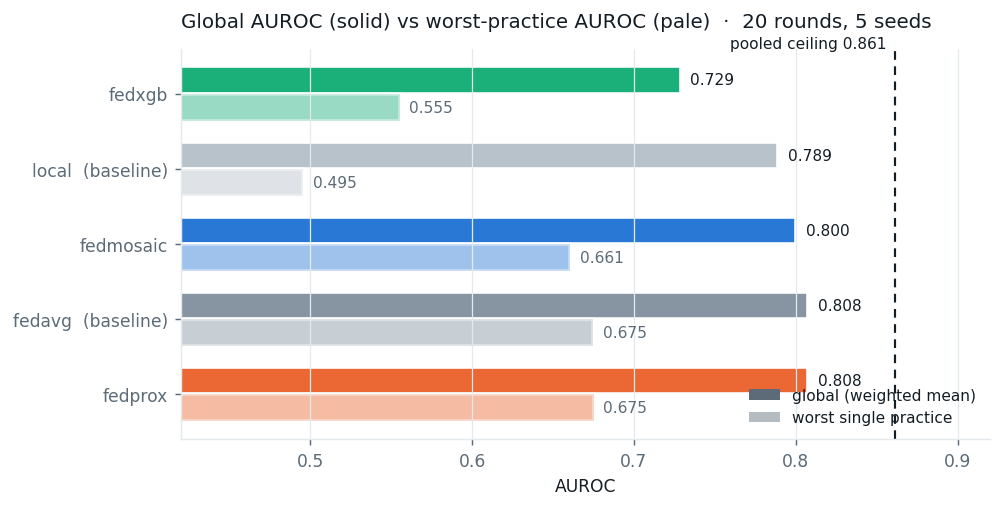

In [7]:
fig, ax = plt.subplots(figsize=(7.8, 4.0))
order = [r for r in clinics.index if r != 'centralized']
y, h = np.arange(len(order)), 0.36

for i, run in enumerate(order):
    c = COLOR[run]
    a, w = clinics.loc[run,'AUROC'], clinics.loc[run,'Worst practice']
    ax.barh(y[i]+h/2, a, height=h, color=c, edgecolor='white', linewidth=2)
    ax.barh(y[i]-h/2, w, height=h, color=c, alpha=.45, edgecolor='white', linewidth=2)
    ax.text(a+.006, y[i]+h/2, f'{a:.3f}', va='center', fontsize=8.5, color=INK)
    ax.text(w+.006, y[i]-h/2, f'{w:.3f}', va='center', fontsize=8.5, color=MUTED)

ax.axvline(CEIL_AUC, color=CEIL, lw=1.2, ls=(0,(4,3)))
ax.text(CEIL_AUC-.005, len(order)-.4, f'pooled ceiling {CEIL_AUC:.3f}',
        ha='right', fontsize=8.5, color=CEIL)

ax.set_yticks(y)
ax.set_yticklabels([r if r in PROTOCOLS else f'{r}  (baseline)' for r in order])
ax.set_xlim(0.42, 0.92); ax.set_xlabel('AUROC')
ax.set_title('Global AUROC (solid) vs worst-practice AUROC (pale)  ·  20 rounds, 5 seeds',
             loc='left', pad=12)
ax.grid(axis='y', visible=False)
ax.legend(handles=[Patch(facecolor=MUTED, label='global (weighted mean)'),
                   Patch(facecolor=MUTED, alpha=.45, label='worst single practice')],
          loc='lower right', fontsize=8.5)
plt.tight_layout(); plt.show()


In [8]:
print('Worst-practice AUROC, averaged over seeds:')
for run in ['local','fedmosaic','fedavg','fedprox']:
    print(f'  {run:<10} {clinics.loc[run,"Worst practice"]:.3f}')
print()
gain = clinics.loc['fedprox','Worst practice'] - clinics.loc['local','Worst practice']
print(f'federating rescues the worst practice by {gain:+.3f} AUROC')
print(f'gap from best federated to pooled ceiling: {clinics.loc["fedprox","AUROC"] - CEIL_AUC:+.3f}')


Worst-practice AUROC, averaged over seeds:
  local      0.495
  fedmosaic  0.661
  fedavg     0.675
  fedprox    0.675

federating rescues the worst practice by +0.180 AUROC
gap from best federated to pooled ceiling: -0.054


---
## 4. Does training longer help?

Everything above was read at round 20. The runs went to 50 — so we can just look.


In [9]:
rows = []
for run in ALL_RUNS:
    for r in CHECKPOINTS:
        rows.append({'run':run, 'rounds':r,
                     'auc':np.mean([at_round('clinics',run,s,r) for s in SEEDS]),
                     'worst':np.mean([at_round('clinics',run,s,r,'auc_worst') for s in SEEDS])})
sweep = pd.DataFrame(rows)

print('AUROC by round'); print(sweep.pivot(index='rounds',columns='run',values='auc').round(3).to_string())
print(); print('WORST PRACTICE by round')
print(sweep.pivot(index='rounds',columns='run',values='worst').round(3).to_string())


AUROC by round


run     fedavg  fedmosaic  fedprox  fedxgb  local
rounds                                           
5        0.805      0.800    0.805   0.780  0.791
10       0.807      0.800    0.807   0.757  0.790
20       0.808      0.800    0.808   0.729  0.789
35       0.808      0.800    0.808   0.703  0.786
50       0.808      0.799    0.808   0.686  0.785

WORST PRACTICE by round
run     fedavg  fedmosaic  fedprox  fedxgb  local
rounds                                           
5        0.671      0.655    0.672   0.599  0.511
10       0.676      0.663    0.675   0.600  0.498
20       0.675      0.661    0.675   0.555  0.495
35       0.677      0.653    0.677   0.521  0.462
50       0.677      0.646    0.677   0.528  0.462


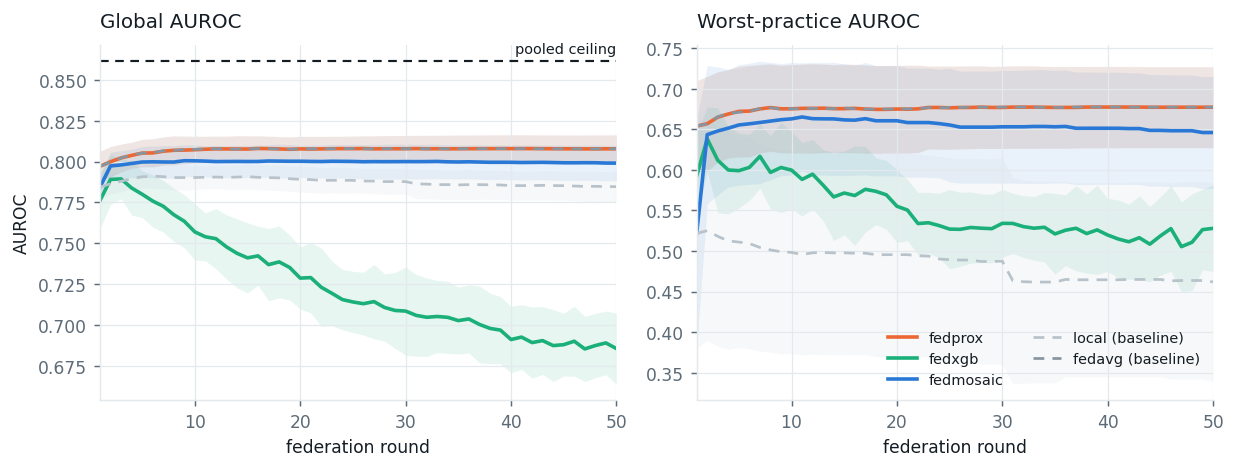

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.7), sharex=True)

for ax, key, title in zip(axes, ['auc','auc_worst'],
                          ['Global AUROC', 'Worst-practice AUROC']):
    for run in ALL_RUNS:
        arr = np.array([[at_round('clinics',run,s,r,key) for r in range(1,ROUNDS+1)]
                        for s in SEEDS], dtype=float)
        m, sd = arr.mean(0), arr.std(0)
        x = np.arange(1, ROUNDS+1)
        proto = run in PROTOCOLS
        ax.plot(x, m, color=COLOR[run], lw=2 if proto else 1.5,
                ls='-' if proto else (0,(4,3)),
                label=run if proto else f'{run} (baseline)')
        ax.fill_between(x, m-sd, m+sd, color=COLOR[run], alpha=.10, linewidth=0)
    if key == 'auc':
        ax.axhline(CEIL_AUC, color=CEIL, lw=1.2, ls=(0,(4,3)))
        ax.text(ROUNDS, CEIL_AUC+.005, 'pooled ceiling', ha='right', fontsize=8, color=CEIL)
    ax.set_title(title, loc='left', pad=10); ax.set_xlabel('federation round')
    ax.set_xlim(1, ROUNDS)
axes[0].set_ylabel('AUROC')
axes[1].legend(fontsize=8, ncols=2, loc='lower right')
plt.tight_layout(); plt.show()


**More rounds do not help — and for one protocol they actively hurt.**

The logistic-regression protocols are converged by round ~10 and flat thereafter; running to 50
buys nothing. `local` drifts *down* slightly as each practice overfits its own small panel.

`fedxgb` is the striking one: it peaks early and then **degrades monotonically**. FedXgbBagging
appends every practice's newly grown trees to one ensemble each round, and under non-IID data those
trees encode contradictory local rules. More rounds means more contradiction, not more signal. If
trees are used at all, the round count is a hyperparameter to tune down, not up.


### Negative control


In [11]:
flat = summarise('flat', 20)
display(flat[['AUROC','±','Worst practice']].style.format('{:.3f}', na_rep='—'))

hi = flat.loc[flat.index != 'centralized', 'AUROC'].max()
print(f'\nhighest AUROC on the signal-less dataset: {hi:.3f}')
print(f"pooled ceiling there:                     {ceiling[('flat','logreg')]['auc']:.3f}")
print('\nPASS - nothing found signal that is not there.' if hi < 0.56 else
      '\nFAIL - a protocol is finding structure that does not exist.')


,AUROC,±,Worst practice
fedxgb,0.528,0.035,0.286
fedprox,0.524,0.030,0.260
fedavg,0.524,0.029,0.260
centralized,0.513,—,—
fedmosaic,0.492,0.026,0.238
local,0.485,0.041,0.266



highest AUROC on the signal-less dataset: 0.528
pooled ceiling there:                     0.513

PASS - nothing found signal that is not there.


---
## 5. Privacy

### What each protocol discloses

Accuracy is half the decision. The other half is what leaves the practice.


In [12]:
# Set max_colwidth to None to display all text
pd.set_option('display.max_colwidth', None)

disc = pd.DataFrame([
    {'run':'fedprox','payload':'model coefficients',
     'what a curious server learns':"a parameter vector fitted to this practice's patients - what gradient-inversion attacks target"},
    {'run':'fedxgb','payload':'serialized trees',
     'what a curious server learns':'split thresholds are literal patient feature values - the highest-disclosure payload here'},
    {'run':'fedmosaic','payload':'predictions + expertise',
     'what a curious server learns':'opinions about patients who are already public - no parameter vector exists to invert'},
]).set_index('run')

disc['bits/round'] = clinics['Uplink bits/round'].round(0)

disc

,payload,what a curious server learns,bits/round
run,,,
fedprox,model coefficients,a parameter vector fitted to this practice's patients - what gradient-inversion attacks target,352.0
fedxgb,serialized trees,split thresholds are literal patient feature values - the highest-disclosure payload here,21521.0
fedmosaic,predictions + expertise,opinions about patients who are already public - no parameter vector exists to invert,3600.0


### What differential privacy costs

Flower's real `DifferentialPrivacyServerSideFixedClipping` over FedAvg, clipping norm 1.0, swept
over noise multipliers, repeated across the same seeds.


In [13]:
dp = run_dp_sweep(rounds=DP_ROUNDS, seeds=tuple(SEEDS))
dp_df = pd.DataFrame(dp)[['noise_multiplier','auc_mean','auc_std','auc_worst_mean',
                          'auc_worst_std','epsilon','epsilon_basic_upper_bound']]
dp_df.columns = ['noise σ','AUROC','±','Worst practice','±w','ε (RDP)','ε naive bound']
dp_df['AUROC cost'] = dp_df['AUROC'] - dp_df.loc[0,'AUROC']
dp_df.set_index('noise σ')[['AUROC','±','Worst practice','ε (RDP)','ε naive bound','AUROC cost']].style.format(
    {'AUROC':'{:.3f}','±':'{:.3f}','Worst practice':'{:.3f}',
     'ε (RDP)':'{:,.1f}','ε naive bound':'{:,.0f}','AUROC cost':'{:+.3f}'}, na_rep='—')

  sigma=0.0   AUROC=0.808±0.008  worst=0.675±0.054  eps=— (naive bound —)
  sigma=0.1   AUROC=0.808±0.007  worst=0.676±0.056  eps=1211.78 (naive bound 969)
  sigma=0.25  AUROC=0.807±0.008  worst=0.669±0.054  eps=244.04 (naive bound 388)
  sigma=0.5   AUROC=0.803±0.011  worst=0.681±0.033  eps=81.12 (naive bound 194)
  sigma=1.0   AUROC=0.794±0.014  worst=0.646±0.061  eps=30.13 (naive bound 97)
  sigma=2.0   AUROC=0.773±0.017  worst=0.608±0.097  eps=12.30 (naive bound 48)


,AUROC,±,Worst practice,ε (RDP),ε naive bound,AUROC cost
noise σ,,,,,,
0.000000,0.808,0.008,0.675,—,—,+0.000
0.100000,0.808,0.007,0.676,"1,211.8",969,-0.000
0.250000,0.807,0.008,0.669,244.0,388,-0.001
0.500000,0.803,0.011,0.681,81.1,194,-0.004
1.000000,0.794,0.014,0.646,30.1,97,-0.014
2.000000,0.773,0.017,0.608,12.3,48,-0.035


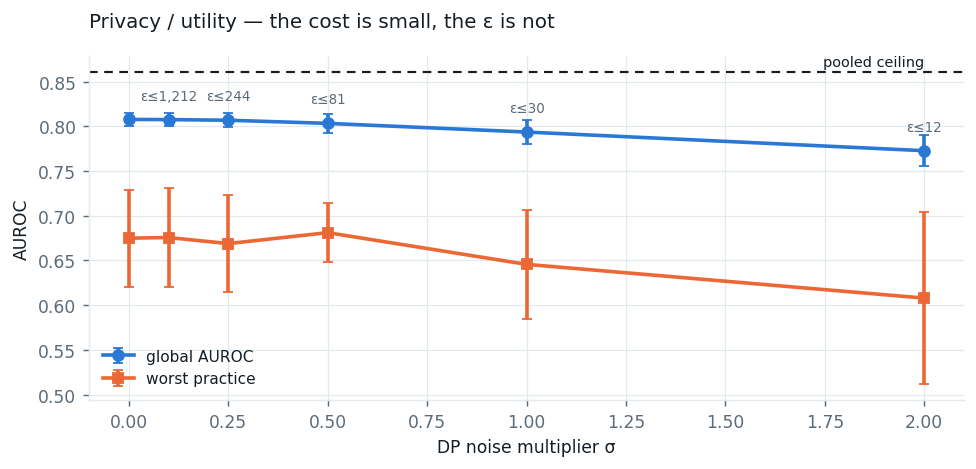

In [14]:
fig, ax = plt.subplots(figsize=(7.6, 3.7))
sig = dp_df['noise σ'].values
ax.errorbar(sig, dp_df['AUROC'], yerr=dp_df['±'], color=COLOR['fedmosaic'],
            lw=2, marker='o', ms=6, capsize=3, label='global AUROC')
ax.errorbar(sig, dp_df['Worst practice'], yerr=dp_df['±w'], color=COLOR['fedprox'],
            lw=2, marker='s', ms=6, capsize=3, label='worst practice')
ax.axhline(CEIL_AUC, color=CEIL, lw=1.2, ls=(0,(4,3)))
ax.text(sig.max(), CEIL_AUC+.006, 'pooled ceiling', ha='right', fontsize=8, color=CEIL)

for x, y, e in zip(sig, dp_df['AUROC'], dp_df['ε (RDP)']):
    if not pd.isna(e):
        ax.annotate(f'ε≤{e:,.0f}', (x, y), textcoords='offset points', xytext=(0,11),
                    ha='center', fontsize=7.5, color=MUTED)

ax.set_xlabel('DP noise multiplier σ'); ax.set_ylabel('AUROC')
ax.set_title('Privacy / utility — the cost is small, the ε is not', loc='left', pad=16)
ax.legend(fontsize=8.5, loc='lower left')
plt.tight_layout(); plt.show()


> **The ε column is the finding, not the AUROC column.**
>
> The tempting read is "DP is nearly free". But the budgets at low noise are enormous — meaningful
> guarantees are single-digit. Getting there means far more noise, and the worst practice degrades
> sharply before ε becomes respectable.
>
> The cause is cohort size: ~3,300 patients across ten practices is very little to hide in. The
> levers are the funded pilot's 25 practices rather than ten, fewer rounds — and §4 just showed the
> logistic protocols are converged by round 10, so **cutting rounds from 50 to 10 costs no accuracy
> and cuts the composed ε about 2.7×** (the RDP accountant: 22.0 → 8.1 at σ = 2.0 — sublinear,
> but still the cheapest ε improvement available). That is the cheapest ε improvement available.
>
> **On the two ε columns.** `ε (RDP)` comes from a Rényi-DP accountant (`dp-accounting`) and is
> what the project reports. `ε naive bound` is the superseded basic-composition figure, shown only
> for comparison: where both are meaningful the accountant is 2–4× tighter, and at low σ the naive
> expression is **not a valid bound at all** (it holds only for per-round ε ≤ 1, which every row
> violates). Do not quote the naive column.
>
> **Central DP does not stop the server seeing individual updates** — its noise is added *during*
> aggregation. Only local DP (`run_local_dp_sweep`, `LocalDpMod`) does, and it costs far more:
> at a comparable composed ε it gives up roughly 0.04 AUROC, and at ε ≈ 4.3 the worst practice
> falls below the no-collaboration baseline. See `docs/PRIVACY.md` §3.

### Is secure aggregation reachable?


In [15]:
sec = probe_secagg()
for k, v in sec.items():
    if k != 'conclusion':
        print(f'  {k:<42} {v}')
print(); print(sec['conclusion'])


  secaggplus_mod_in_new_namespace            False
  dp_mods_in_new_namespace                   ['fixedclipping_mod', 'adaptiveclipping_mod', 'LocalDpMod']
  secaggplus_mod_in_legacy_namespace         True
  secaggplus_workflow_available              True
  requires_legacy_context                    True
  implemented_in_this_repo                   True

SecAgg+ ships only in the legacy namespaces: the workflow requires a LegacyContext and the client mod exists only in flwr.client.mod, not flwr.clientapp.mod. It therefore cannot be composed with strategy.start() on the Message API. It IS reachable by driving DefaultWorkflow(fit_workflow=SecAggPlusWorkflow(...)) with a LegacyContext from inside a modern ServerApp — and that path is now IMPLEMENTED and verified end-to-end here: server_app._run_secure_aggregation, enabled with `secure-aggregation = true`, runs fit and evaluate to completion with 0 failures over 12 practices. The ClientApp accepts both the Message-API record shape and the 

---
## 6. What this says

**Federation gets within ~0.05 AUROC of the pooled ceiling** (0.808 vs 0.861) without any practice
sharing a patient row. That is the core FLIP-IT claim, and it holds.

**The benefit is equity, not average accuracy.** Global AUROC separates training-alone from the best
protocol by roughly 0.02. The worst practice separates them by an order of magnitude more — from
about 0.50 to about 0.675. For a pilot whose premise is that small independent practices should get
a model they could not build alone, that is the number that matters.

**FedProx and FedAvg are indistinguishable here**, and both edge out FedMosaic across seeds. The
proximal term has almost no drift to correct at two local epochs per round. FedMosaic's appeal is
its disclosure profile, not its accuracy — it never transmits a model.

**Do not deploy XGBoost.** Its pooled ceiling matches logistic regression (0.860 vs 0.861) but it
federates far worse, degrades with more rounds, costs orders of magnitude more bandwidth, and —
shipping trees rather than a vector — secure aggregation cannot protect it at all.

**Cut the round count.** Converged by round 10; every extra round spends privacy budget for nothing.

### Limitations

| Limitation | Consequence |
|---|---|
| Synthetic data throughout | Absolute AUROC is not a clinical claim |
| No eGFR | The strongest CKD predictor is missing; real data should lift every number |
| Synthetic label is prevalence, real label is incidence | Different prediction tasks (CLAUDE.md §3b) |
| Ten practices, not 25 | Understates the pilot, especially for the privacy budget |
| Worst-practice has high seed variance | Reported ± is wide; treat single-seed results as unreliable |
| Fairness by age band, not sex | `geschlecht` exists only in the real schema |
| Inversion/reconstruction attack audits still open | Membership inference is tested and clean (audit.py); the other two EDPB attack families remain unaudited |
| DP measured on FedAvg only | FedProx / FedMosaic DP costs unmeasured |

---
Full write-ups: [`docs/REPORT.md`](../docs/REPORT.md) · [`docs/PRIVACY.md`](../docs/PRIVACY.md) ·
[`docs/DEPLOYMENT.md`](../docs/DEPLOYMENT.md)
